<a href="https://colab.research.google.com/drive/1rmca_f2jODDNDlzzP2gIzkIiQCNRMj0Y?usp=sharing" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Week3-APPSREV-BRImo
### Nabila Shinta Luthfia
### 5026231038

In [1]:
#Instalasi Library
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00


In [2]:
# Import Library
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [3]:
# Upload dan load dataset ke google colab
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

# Melakukan iterasi pada setiap file yang diunggah
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  try:
    df_brimo = pd.read_csv(io.BytesIO(uploaded[fn]))
    print("Successfully loaded CSV into df_jknrev")
  except pd.errors.ParserError:
      print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
      df_brimo = pd.DataFrame() # Create an empty DataFrame if parsing fails
  except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df_brimo = pd.DataFrame()

Saving brimo_raw_reviews.csv to brimo_raw_reviews.csv
User uploaded file "brimo_raw_reviews.csv" with length 377243872 bytes
Successfully loaded CSV into df_jknrev


In [4]:
df_brimo

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,69f29837-ef0f-4ff8-bfa3-990179e35552,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantab dan cepat,5,0,NaN,2026-03-16 02:28:53,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:40:52,NaN
1,284b1e08-aab1-4302-a907-f6e1cb281a82,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lebih mudah nyaman transaksi,5,0,2.95.0,2026-03-16 02:27:37,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:43:35,2.95.0
2,7c5b811e-d163-413a-8e7c-52493eca68d8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,5,0,2.94.0,2026-03-16 02:19:08,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:41:24,2.94.0
3,88f8abeb-2efd-41c9-b393-29d37d776748,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat puas,5,0,2.95.0,2026-03-16 02:14:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:42:49,2.95.0
4,10cb1623-3478-4d06-a88a-47a180be3e9a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mudah dan sangat membantu,5,0,NaN,2026-03-16 02:06:05,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:42:31,NaN
...,...,...,...,...,...,...,...,...,...,...,...
859080,0a2174b1-890f-4fea-8317-4cb783d02066,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jozz,5,1,1.3.0,2019-02-26 05:49:31,NaN,NaN,1.3.0
859081,d93d6edf-3844-4420-abd7-166691b1f791,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semakin canggih aplikasi BRI dan dipermudah lagi,5,2,NaN,2019-02-26 05:43:51,NaN,NaN,NaN
859082,042cc988-7ef1-4ba2-a574-05d35372b2fb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantapsss,5,0,1.3.0,2019-02-26 05:38:54,NaN,NaN,1.3.0
859083,97f21f6d-6e84-446e-8573-b0820ac777aa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gooooooood,5,1,1.3.0,2019-02-26 05:31:38,NaN,NaN,1.3.0


In [5]:
df_brimo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 859085 entries, 0 to 859084
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              859085 non-null  object
 1   userName              859085 non-null  object
 2   userImage             859085 non-null  object
 3   content               859084 non-null  object
 4   score                 859085 non-null  int64 
 5   thumbsUpCount         859085 non-null  int64 
 6   reviewCreatedVersion  723371 non-null  object
 7   at                    859085 non-null  object
 8   replyContent          853756 non-null  object
 9   repliedAt             853756 non-null  object
 10  appVersion            723371 non-null  object
dtypes: int64(2), object(9)
memory usage: 72.1+ MB


In [6]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download Indonesian stopwords
nltk.download('stopwords')
indonesian_stopwords = set(stopwords.words('indonesian'))

# Menentukan target kolom yang akan dianalisis
text_column = 'content'  # Change this if the column has a different name

# Penggabungan data
all_text = ' '.join(df_brimo[text_column].dropna().astype(str))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
df_brimo.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,mantab dan cepat,5,0,NaN,2026-03-16 02:28:53,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:40:52
1,lebih mudah nyaman transaksi,5,0,2.95.0,2026-03-16 02:27:37,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:43:35
2,bagus,5,0,2.94.0,2026-03-16 02:19:08,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:41:24
3,sangat puas,5,0,2.95.0,2026-03-16 02:14:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-16 02:42:49
4,sangat mudah dan sangat membantu,5,0,NaN,2026-03-16 02:06:05,"Hai Sobat BRI, terima kasih atas ulasannya 😊. ...",2026-03-16 02:42:31
...,...,...,...,...,...,...,...
859080,jozz,5,1,1.3.0,2019-02-26 05:49:31,NaN,NaN
859081,semakin canggih aplikasi BRI dan dipermudah lagi,5,2,NaN,2019-02-26 05:43:51,NaN,NaN
859082,mantapsss,5,0,1.3.0,2019-02-26 05:38:54,NaN,NaN
859083,gooooooood,5,1,1.3.0,2019-02-26 05:31:38,NaN,NaN


## Stopwords Removal

### Indonesian Stopwords

In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

indonesian_stopwords = stopwords.words('indonesian')

# DMenampilkan 20 kata pertama dari daftar untuk verifikasi data
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
print(len(indonesian_stopwords))

758


In [12]:
indonesian_stopwords

['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

,Word,Frequency
0,brimo,94142
1,membantu,92100
2,aplikasi,81902
3,bagus,73514
4,mudah,67868
...,...,...
95,salah,6340
96,pembayaran,6289
97,alhamdulillah,6269
98,no,6191


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


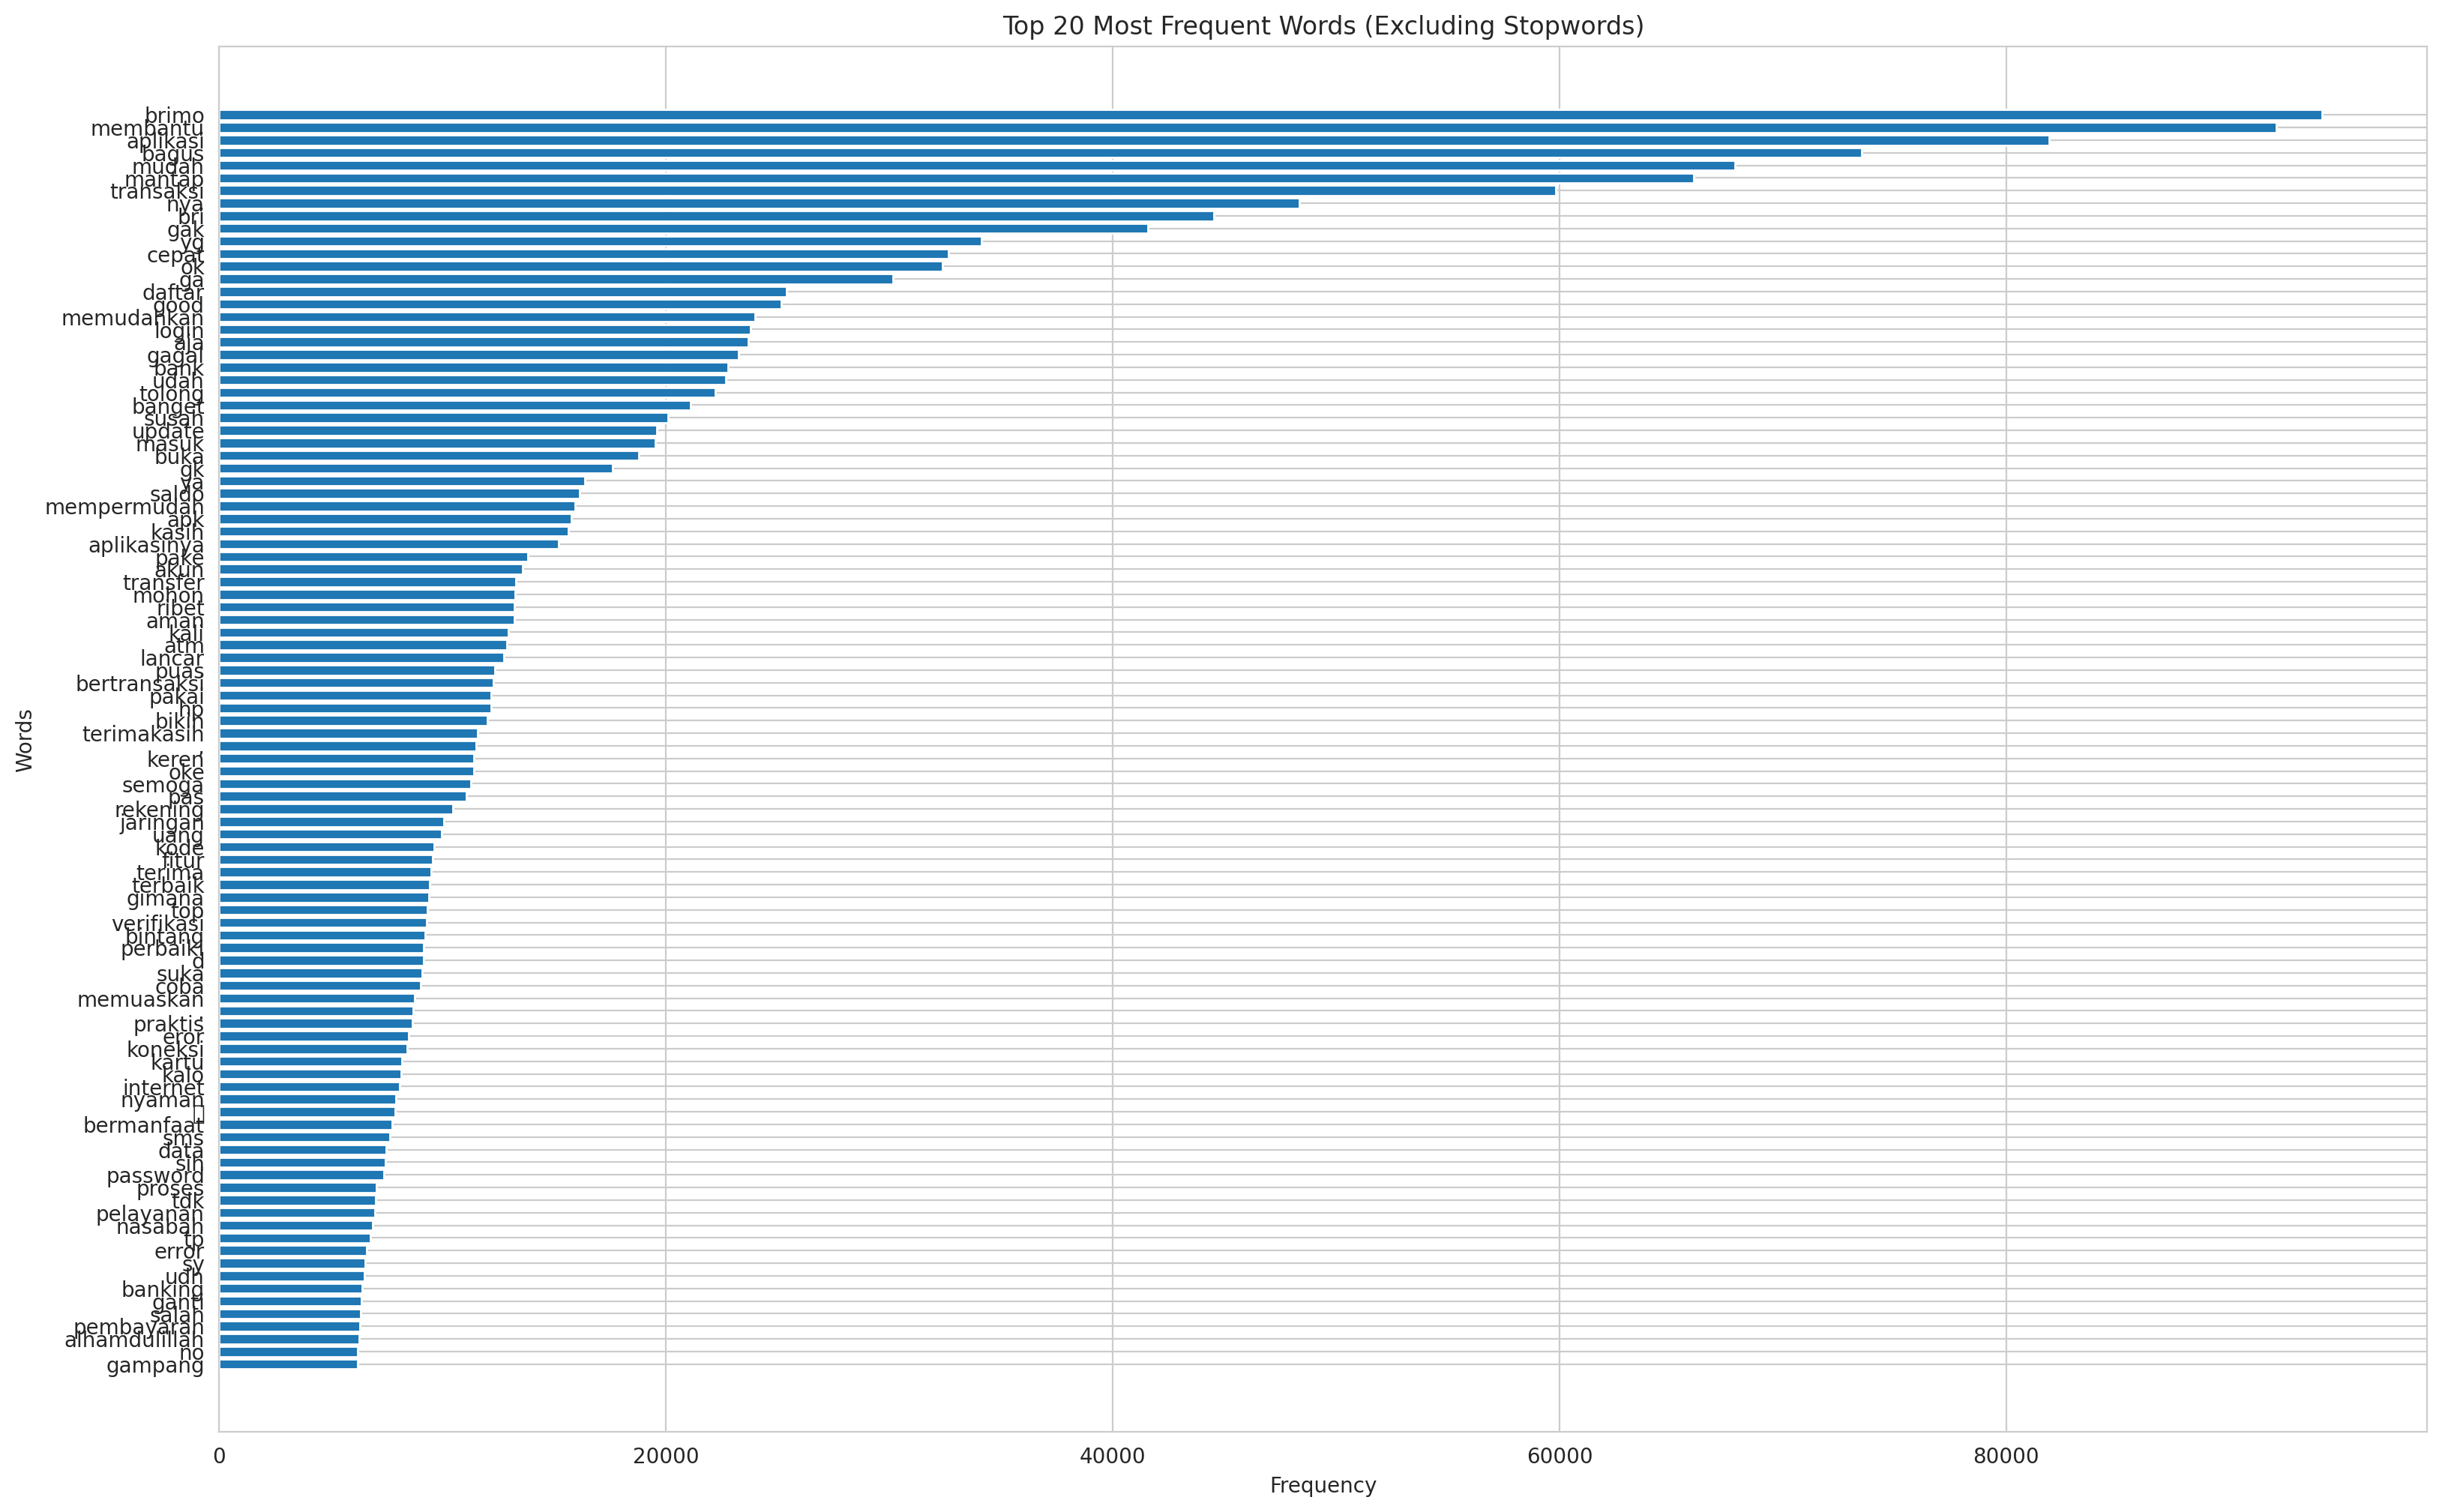

In [13]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Menentukan kolom target
text_column = 'content'

all_text = ' '.join(df_brimo[text_column].dropna().astype(str))

# Tokenisasi
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

# Untuk menghitung berapa kali setiap kata muncul
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

display(word_freq_df)

plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [14]:
common_words

[('brimo', 94142),
 ('membantu', 92100),
 ('aplikasi', 81902),
 ('bagus', 73514),
 ('mudah', 67868),
 ('mantap', 66011),
 ('transaksi', 59846),
 ('nya', 48358),
 ('bri', 44539),
 ('gak', 41568),
 ('yg', 34105),
 ('cepat', 32661),
 ('ok', 32388),
 ('ga', 30165),
 ('daftar', 25381),
 ('good', 25158),
 ('memudahkan', 23975),
 ('login', 23787),
 ('aja', 23686),
 ('gagal', 23239),
 ('bank', 22778),
 ('udah', 22668),
 ('tolong', 22192),
 ('banget', 21106),
 ('susah', 20101),
 ('update', 19604),
 ('masuk', 19524),
 ('buka', 18781),
 ('gk', 17598),
 ('ya', 16370),
 ('saldo', 16124),
 ('mempermudah', 15925),
 ('apk', 15753),
 ('kasih', 15636),
 ('aplikasinya', 15205),
 ('pake', 13799),
 ('akun', 13581),
 ('transfer', 13266),
 ('mohon', 13240),
 ('ribet', 13224),
 ('aman', 13215),
 ('kali', 12942),
 ('atm', 12887),
 ('lancar', 12755),
 ('puas', 12343),
 ('bertransaksi', 12267),
 ('pakai', 12167),
 ('hp', 12162),
 ('bikin', 12005),
 ('terimakasih', 11562),
 (',', 11503),
 ('keren', 11393),
 ('oke

,Word,Frequency
0,membantu,92100
1,bagus,73514
2,mudah,67868
3,mantap,66011
4,transaksi,59846
...,...,...
95,kendala,4676
96,best,4662
97,sdh,4662
98,klo,4660


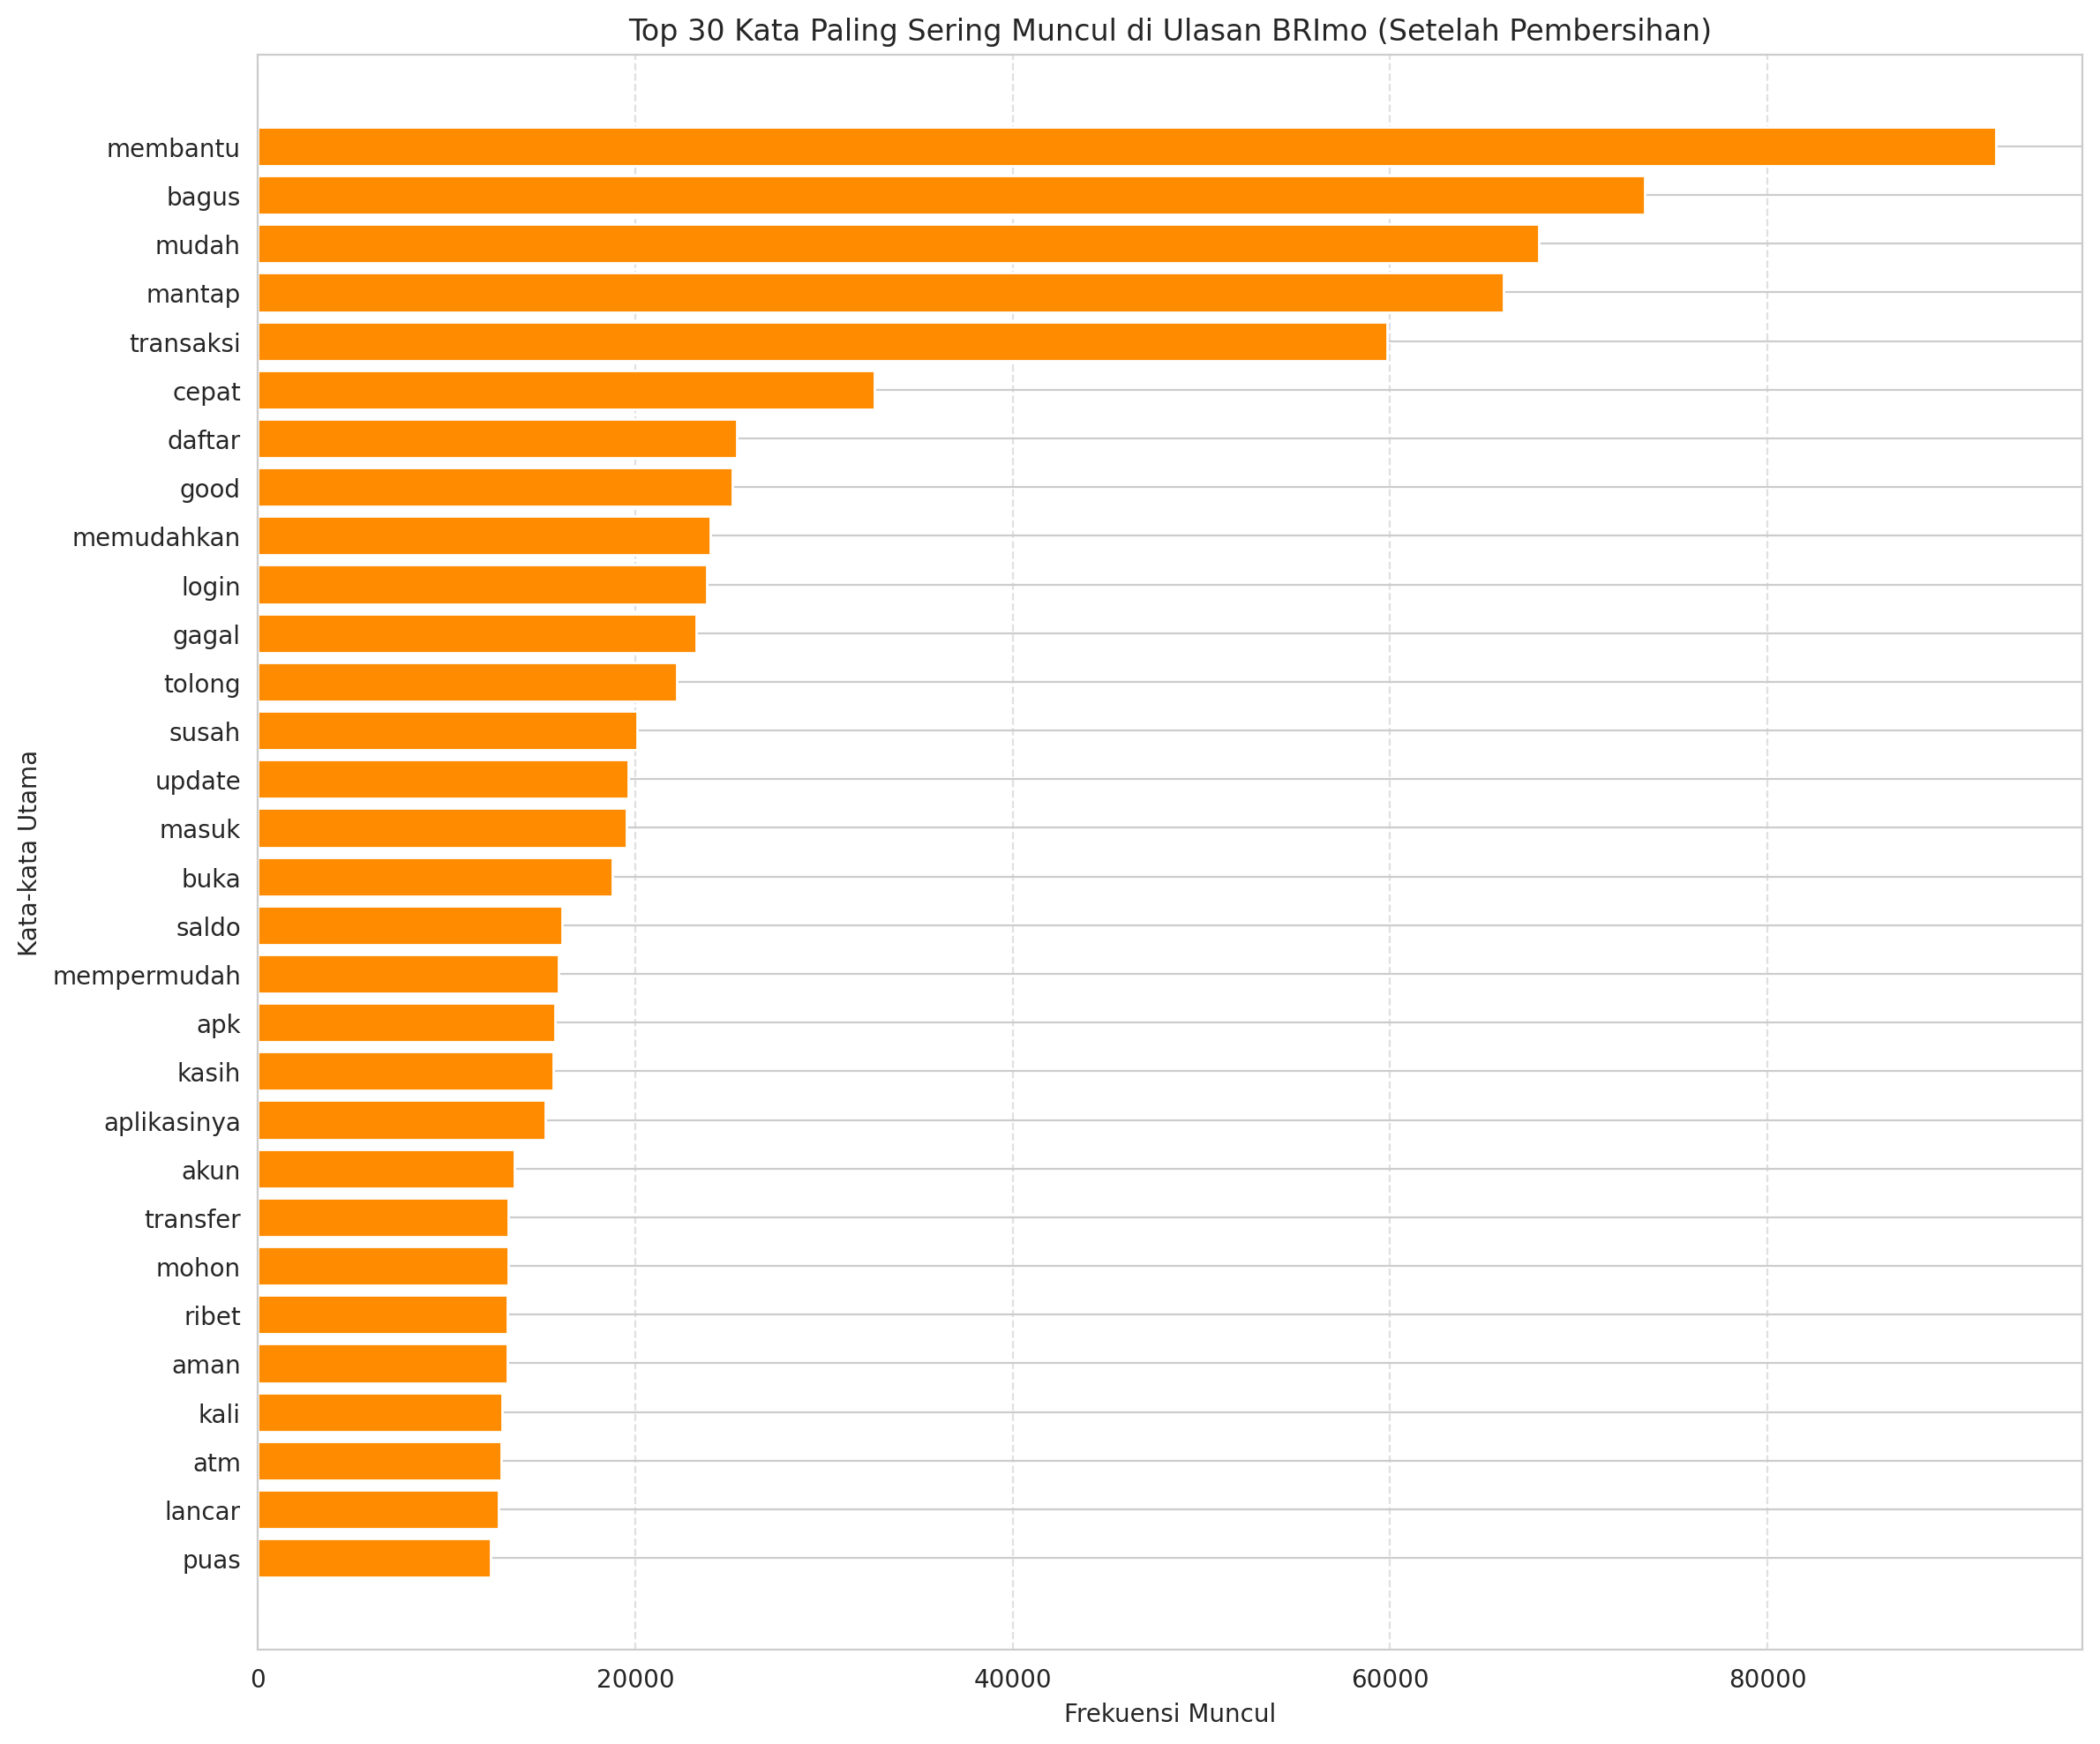

In [15]:
# Penambahan list kata

import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Mengambil list dasar dari NLTK (Bahasa Indonesia)
try:
    indonesian_stopwords = stopwords.words('indonesian')
except:
    import nltk
    nltk.download('stopwords')
    indonesian_stopwords = stopwords.words('indonesian')

# Menambahkan list kata sampah buatan sendiri (slang & tidak bermakna)
slang_stopwords = [
    'ga', 'gak', 'yg', 'dan', 'di', 'ke', 'ini', 'itu', 'ada', 'bgt', 'banget',
    'aja', 'saja', 'ya', 'udah', 'sudah', 'lu', 'gue', 'gw', 'ok', 'oke',
    'kalo', 'kalau', 'pake', 'pakai', 'krn', 'karena', 'jadi', 'jd', 'tapi',
    'tp', 'pas', 'buat', 'untuk', 'dari', 'kok', 'sih', 'deh', 'dong', 'doang',
    'sama', 'sm', 'gak', 'gk', 'enggak', 'tdk', 'tidak', 'adalah', 'punya',
    'ingin', 'mau', 'bisa', 'dapat', 'lagi', 'lg', 'ny', 'nya', 'nih', 'tuh',
    'biar', 'supaya', 'biarin', 'lah', 'kah', 'is', 'the', 'and', 'brimo',
    'aplikasi', 'apps', 'app', 'bank', 'bri', 'admin', 'halo', 'min', 'kak'
]

# Menggabungkan semua
indonesian_stopwords.extend(slang_stopwords)
# Menghapus duplikat agar lebih efisien
indonesian_stopwords = list(set(indonesian_stopwords))

text_column = 'content'

# Mengabungkan semua teks dan bersihkan NaN
all_text = ' '.join(df_brimo[text_column].dropna().astype(str))

# Tokenisasi dan filter
# word.isalpha() membuang angka & tanda baca
# len(word) > 2 membuang singkatan satu/dua huruf yang tidak penting
words = all_text.split()
filtered_words = [
    word.lower() for word in words
    if word.lower() not in indonesian_stopwords
    and word.isalpha()
    and len(word) > 2
]

word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# DataFrame hasil
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
display(word_freq_df)

# Visualisasi
plt.figure(figsize=(12, 10))
# Plot top 30
top_plot = word_freq_df.head(30)
plt.barh(top_plot['Word'][::-1], top_plot['Frequency'][::-1], color='darkorange')
plt.xlabel("Frekuensi Muncul")
plt.ylabel("Kata-kata Utama")
plt.title("Top 30 Kata Paling Sering Muncul di Ulasan BRImo (Setelah Pembersihan)")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [16]:
common_words

[('membantu', 92100),
 ('bagus', 73514),
 ('mudah', 67868),
 ('mantap', 66011),
 ('transaksi', 59846),
 ('cepat', 32661),
 ('daftar', 25381),
 ('good', 25158),
 ('memudahkan', 23975),
 ('login', 23787),
 ('gagal', 23239),
 ('tolong', 22192),
 ('susah', 20101),
 ('update', 19604),
 ('masuk', 19524),
 ('buka', 18781),
 ('saldo', 16124),
 ('mempermudah', 15925),
 ('apk', 15753),
 ('kasih', 15636),
 ('aplikasinya', 15205),
 ('akun', 13581),
 ('transfer', 13266),
 ('mohon', 13240),
 ('ribet', 13224),
 ('aman', 13215),
 ('kali', 12942),
 ('atm', 12887),
 ('lancar', 12755),
 ('puas', 12343),
 ('bertransaksi', 12267),
 ('bikin', 12005),
 ('terimakasih', 11562),
 ('keren', 11393),
 ('semoga', 11265),
 ('rekening', 10462),
 ('jaringan', 10049),
 ('uang', 9967),
 ('kode', 9608),
 ('fitur', 9541),
 ('terima', 9494),
 ('terbaik', 9403),
 ('gimana', 9394),
 ('top', 9317),
 ('verifikasi', 9278),
 ('bintang', 9232),
 ('perbaiki', 9159),
 ('suka', 9093),
 ('coba', 9021),
 ('memuaskan', 8747),
 ('prakti